# 04 · 가산 run 모델의 다항시간 해법과 한계

## 문제

$$F_n(\lambda)=\max_{M\in\{0,1\}^n}\bigl\{I(M)-\lambda L_T(M)\bigr\},\qquad\lambda\ge0.$$

이는 비율 목적과 다르다. $\lambda$는 importance/ms 단위다. cardinality나 quality 제약을 없앤 scalarized 문제를 정확히 풀며, empty mask도 허용한다.

## 실행 준비

결과는 `runs/04_polynomial_dp/`에 저장합니다. 이 셀을 다시 실행하면 해당 폴더의 이전 결과를 지우고 새로 만듭니다.

In [1]:
from pathlib import Path
import sys
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
RUN = begin(ROOT, "04_polynomial_dp", SEED)

**결과:** `runs/04_polynomial_dp/` · seed `20260926`

## 정리 2 · 임의의 table에서 $O(n^2)$

$P_j=\sum_{i<j}v_i$, $F_j$를 첫 $j$개 채널의 최적값으로 두고 $F_0=0$으로 초기화한다.

$$\boxed{F_j=\max\left\{F_{j-1},\max_{0\le a<j}\left[F_{\max(0,a-1)}+P_j-P_a-\lambda T(j-a)\right]\right\}.}$$

**증명.** 마지막 채널이 0이면 $F_{j-1}$. 1이면 마지막 최대 run은 유일한 $[a,j)$다. $a>0$일 때 직전 채널 $a-1$은 반드시 0이므로 앞부분은 $F_{a-1}$이다. 이 조건이 없으면 인접한 run을 두 번 나눠 과금하는 잘못된 문제가 된다. 각 경우의 최적 prefix를 연결하면 feasible하므로 상·하한이 일치한다. $j=1,\ldots,n$에 대해 귀납한다. 최적 선택의 $a$를 저장하여 mask를 복원한다.

길이별 table에 convexity나 monotonicity는 필요 없다. 시간은 $\sum_jj=O(n^2)$, 값과 predecessor 메모리는 $O(n)$이다. 실험 코드의 vectorized temporary도 $O(n)$이다.

## 정리 3 · plateau two-line이면 $O(n)$

$$T(\ell)=\begin{cases}a_0+b_1\ell&1\le\ell\le s,\\b_2\ell&\ell>s,\end{cases}
\quad a_0=(b_2-b_1)s,\quad0\le b_1\le b_2.$$

길이가 짧은 transition에서 $a$에 의존하는 부분은

$$U_a=F_{\max(0,a-1)}-P_a+\lambda b_1a,\quad
P_j-\lambda(a_0+b_1j)+\max_{j-s\le a<j}U_a.$$

긴 transition에서는

$$V_a=F_{\max(0,a-1)}-P_a+\lambda b_2a,\quad
P_j-\lambda b_2j+\max_{0\le a<j-s}V_a.$$

첫 최대값은 길이 $s$의 monotone deque, 둘째는 누적 최대값으로 유지한다. 각 index가 deque에 한 번 들어가고 한 번 빠지므로 amortized $O(n)$ 시간, traceback 포함 $O(n)$ 메모리다. “빠른 근사”가 아니라 **해당 two-line 모델의 정확해**다. 실측 table을 두 직선으로 맞추는 오차는 이 정리의 바깥에 있다.

In [2]:
checks = []
for n in [1, 5, 10, 14]:
    for s in [1, 4, n + 2]:
        v = C.workload(n, SEED + n, "spiky")
        cost = C.two_line(n, s)
        masks, imp, delay = C.exhaustive(v, cost)
        for penalty in [0., .1, 1., 10.]:
            slow = C.lagrangian(v, cost, penalty)
            fast = C.linear_lagrangian(v, s, .03, .12, penalty)
            objective = lambda m: v[m].sum() - penalty * C.latency(m, cost)
            oracle = float((imp - penalty * delay).max())
            assert np.isclose(objective(slow), oracle)
            assert np.isclose(objective(fast), oracle)
            checks.append(dict(n=n, s=s, penalty=penalty, oracle=oracle, slow=objective(slow), fast=objective(fast)))
pd.DataFrame(checks).to_csv(RUN / "exactness.csv", index=False)


## 검증

서로 독립적인 complete enumeration, 일반 DP, 선형 DP의 objective 값을 작은 입력에서 비교한다. tie에서는 mask 자체가 달라도 optimum 값이 같으면 통과한다. $s=1$, $s>n$, $\lambda=0$, 모든 importance가 0인 경계도 검사한다. 별도 size sweep에서 실제 CPU 시간을 측정한다. 점근적 증명과 제한된 크기에서의 timing curve를 구분한다.

In [2]:
timings = []
for n in [128, 256, 512, 1024, 2048, 4096]:
    v, cost = C.workload(n, SEED), C.two_line(n, 32)
    for method, solve in [("General O(n^2)", lambda: C.lagrangian(v, cost, 6.)),
                          ("Two-line O(n)", lambda: C.linear_lagrangian(v, 32, .03, .12, 6.))]:
        solve()
        for repeat in range(5):
            start = perf_counter()
            mask = solve()
            timings.append(dict(n=n, method=method, repeat=repeat, milliseconds=1000 * (perf_counter() - start)))
timeframe = pd.DataFrame(timings)
timeframe.to_csv(RUN / "runtime_raw.csv", index=False)


## 고정 cardinality와 coverage를 혼동하지 않기

$|M|=r$까지 강제하면 $F_{j,r}$로 확장할 수 있다.

$$F_{j,r}=\max\left\{F_{j-1,r},\max_{\ell\le\min(j,r)}
F_{\max(0,j-\ell-1),r-\ell}+P_j-P_{j-\ell}-\lambda T(\ell)\right\}.$$

초기값 $F_{0,0}=0$, impossible state $=-\infty$를 주면 일반 table은 $O(n^2R)$다. 이 부가 recurrence는 복잡도 분석이고 노트북 구현·측정은 scalarized 두 해법에 집중한다.

integer importance로 quality state를 추가하는 DP의 크기는 수치 합에 의존한다. 이를 입력 **bit 수**에 대한 다항시간이라고 부를 수 없다. 이 관찰만으로 원래 문제의 NP-hardness를 주장하지도 않는다.

## Lagrange sweep은 Pareto 전체가 아니다

$$I(M)-\lambda L(M)=\text{constant}$$

직선이 위에서 닿는 supported point만 scalarization으로 얻는다. 비볼록 이산 Pareto 경계의 unsupported point는 어떤 $\lambda$에서도 선택되지 않을 수 있다. 노트북은 완전탐색 경계의 upper concave hull을 정확하게 구성하여 unsupported 점을 표시한다. 유한한 $\lambda$ grid가 점을 놓친 것과 구분한다.

또한 $\lambda>0$에서

$$D_Q(\lambda)=\frac{Q-F_n(\lambda)}\lambda\le L^*(Q)$$

는 coverage latency의 하한이다. feasible mask의 latency는 상한을 주므로 gap certificate를 만들 수 있다. duality gap이 0이라는 보장은 없다. 완전탐색 Pareto의 unsupported 점의 importance를 $Q$로 택해 이를 직접 확인한다. upper concave hull에서 $Q$의 양옆 점을 $(L_a,I_a),(L_b,I_b)$라 두면 $\lambda=(I_b-I_a)/(L_b-L_a)$가 그 선분을 지지한다. 이 $\lambda$의 dual bound와 hull을 혼합한 relaxation latency가 일치하는지 검사하고, **정확한 relaxation gap**과 유한 $\lambda$ grid의 탐색 오차를 별도로 기록한다. hull의 선형 보간은 여기서만 fractional relaxation에 쓰며 실제 feasible mask를 만들었다고 간주하지 않는다.

In [3]:
v = np.array([7., 1., 2., 8., 1., 6., 2., 9., 1., 3.])
cost = C.two_line(len(v), 3)
masks, imp, delay = C.exhaustive(v, cost)
pareto = C.frontier(imp, delay)
hull = []
for point in pareto:
    while len(hull) >= 2:
        a, b = hull[-2:]
        left = (imp[b] - imp[a]) / (delay[b] - delay[a])
        right = (imp[point] - imp[b]) / (delay[point] - delay[b])
        if left >= right - 1e-12:
            break
        hull.pop()
    hull.append(point)
unsupported = np.setdiff1d(pareto, hull)
# Check any point removed as collinear separately; only strict gaps are unsupported.
unsupported = unsupported[imp[unsupported] < np.interp(delay[unsupported], delay[hull], imp[hull]) - 1e-10]
q = float(imp[unsupported[len(unsupported)//2]])
assert len(unsupported) > 0
exact_coverage = float(delay[imp >= q].min())
penalties = np.geomspace(.1, 100, 100)
dual = [(q - (imp - lam * delay).max()) / lam for lam in penalties]
best_lower = max(0., max(dual))
j = int(np.searchsorted(imp[hull], q))
a, b = hull[j-1], hull[j]
exact_penalty = (imp[b]-imp[a]) / (delay[b]-delay[a])
exact_dual = float((q - (imp-exact_penalty*delay).max()) / exact_penalty)
hull_relaxation = float(np.interp(q, imp[hull], delay[hull]))
assert np.isclose(exact_dual, hull_relaxation)
assert best_lower <= exact_dual + 1e-10 < exact_coverage

## 관측과 판정 · 실행 시간, 이산 Pareto, dual 하한

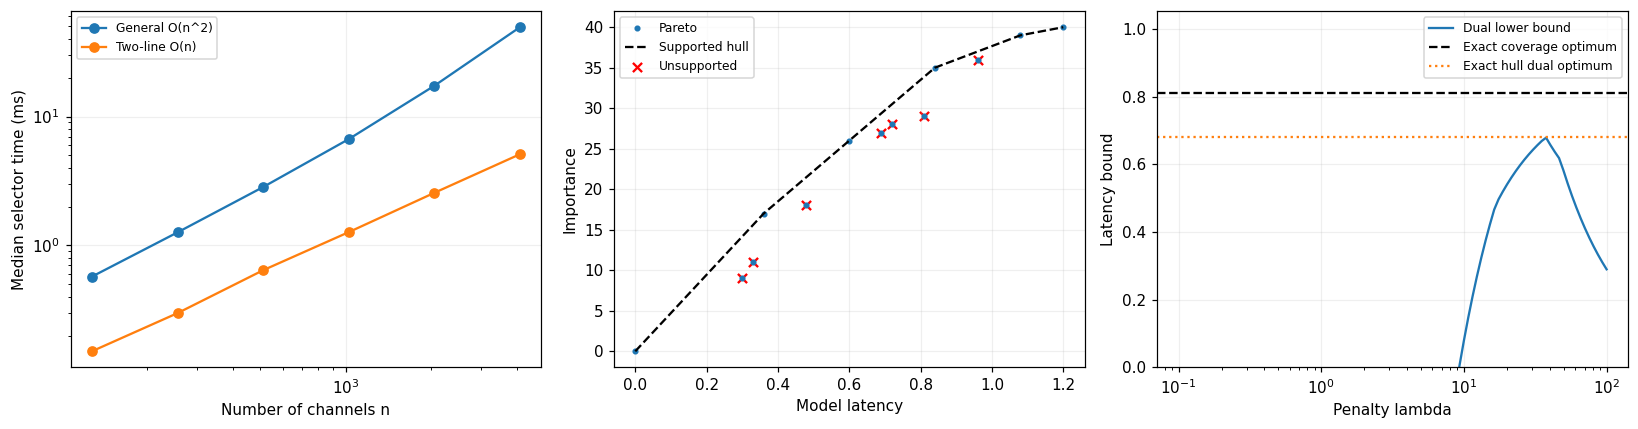

**실행에서 확인한 값**

- **oracle_checks**: 48

- **unsupported_points**: 7

- **coverage_optimum**: 0.8099999999999999

- **grid_dual_lower_bound**: 0.6787305339536024

- **exact_hull_dual_bound**: 0.68

- **duality_gap**: 0.1299999999999999

- **lambda_grid_error**: 0.0012694660463976604

- **scope**: Both DPs are exact for their scalarized models; lambda sweep is not full coverage optimization

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, group in timeframe.groupby("method"):
    med = group.groupby("n").milliseconds.median()
    axes[0].loglog(med.index, med, "o-", label=method)
axes[0].set(xlabel="Number of channels n", ylabel="Median selector time (ms)")
axes[0].legend(fontsize=8)
axes[1].plot(delay[pareto], imp[pareto], ".", label="Pareto")
axes[1].plot(delay[hull], imp[hull], "k--", label="Supported hull")
axes[1].scatter(delay[unsupported], imp[unsupported], marker="x", color="red", label="Unsupported")
axes[1].set(xlabel="Model latency", ylabel="Importance")
axes[1].legend(fontsize=8)
axes[2].semilogx(penalties, dual, label="Dual lower bound")
axes[2].axhline(exact_coverage, color="black", ls="--", label="Exact coverage optimum")
axes[2].axhline(exact_dual, color="tab:orange", ls=":", label="Exact hull dual optimum")
axes[2].set(xlabel="Penalty lambda", ylabel="Latency bound", ylim=(0, exact_coverage * 1.3))
axes[2].legend(fontsize=8)
figure(RUN, "polynomial_and_duality")
finish(RUN, oracle_checks=len(checks), unsupported_points=len(unsupported),
       coverage_optimum=exact_coverage, grid_dual_lower_bound=best_lower,
       exact_hull_dual_bound=exact_dual, duality_gap=exact_coverage-exact_dual,
       lambda_grid_error=exact_dual-best_lower,
       scope="Both DPs are exact for their scalarized models; lambda sweep is not full coverage optimization")